In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
from src.data.preprocessing import prepare_dataset
from sklearn.model_selection import train_test_split
from src.data.dataset import BrainMRIDataset
from torch.utils.data import DataLoader
from src.models.classifier import SimpleCNN
import torch
import torch.nn as nn

In [2]:
DATA_DIR = "../data/raw/kaggle_3m"
df = prepare_dataset(DATA_DIR)

In [3]:
print(f"Total number of rows: {len(df)}")
df.head()

Total number of rows: 3929


,patient_id,image_path,mask_path,has_tumor
0,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,False
1,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,True
2,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,True
3,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,True
4,TCGA_CS_4941_19960909,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,..\data\raw\kaggle_3m\TCGA_CS_4941_19960909\TC...,True


In [4]:
unique_patients = df["patient_id"].unique()

In [5]:
train_patients, temp_patients = train_test_split(
    unique_patients, test_size=0.3, random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.5, random_state=42
)

print(f"Number of patients train: {len(train_patients)}")
print(f"Number of patients val: {len(val_patients)}")
print(f"Number of patients test: {len(test_patients)}")

Number of patients train: 77
Number of patients val: 16
Number of patients test: 17


In [6]:
train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
val_df = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)
test_df = df[df["patient_id"].isin(test_patients)].reset_index(drop=True)

print(f"Number of images train: {len(train_df)}")
print(f"Number of images val: {len(val_df)}")
print(f"Number of images test: {len(test_df)}")

Number of images train: 2750
Number of images val: 618
Number of images test: 561


In [7]:
for name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    tumor_pct = split_df["has_tumor"].mean() * 100
    print(f"{name}: {tumor_pct:.1f}% Has a tumor")

Train: 33.3% Has a tumor
Val: 37.9% Has a tumor
Test: 39.9% Has a tumor


In [8]:
train_dataset = BrainMRIDataset(train_df, image_size=128)

print(f"Number of train_dataset: {len(train_dataset)}")

image, label = train_dataset[0]
print(f"Image shape: {image.shape}")
print(f"Image data type: {image.dtype}")
print(f"Label value: {label}")
print(f"Min/Max pixel value: {image.min():.3f} / {image.max():.3f}")

Number of train_dataset: 2750
Image shape: torch.Size([3, 128, 128])
Image data type: torch.float32
Label value: 1.0
Min/Max pixel value: 0.000 / 0.831


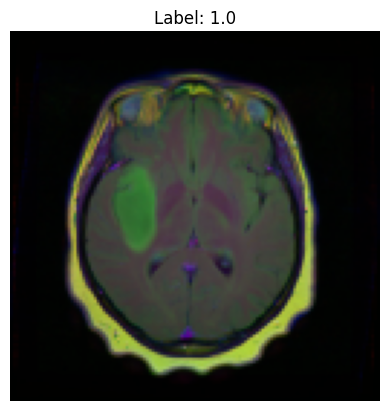

In [9]:
import matplotlib.pyplot as plt

image_np = image.numpy()
image_np = np.transpose(image_np, (1, 2, 0))

plt.imshow(image_np)
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

In [10]:
val_dataset = BrainMRIDataset(val_df, image_size=128)
test_dataset = BrainMRIDataset(test_df, image_size=128)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of train batches: {len(train_loader)}")
print(f"Number of val batches: {len(val_loader)}")
print(f"Number of test batches {len(test_loader)}")

Number of train batches: 86
Number of val batches: 20
Number of test batches 18


In [11]:
model = SimpleCNN()

sample_images, sample_labels = next(iter(train_loader))

print(f"Input shape: {sample_images.shape}")

output = model(sample_images)

print(f"Model output shape: {output.shape}")
print(f"Some raw output samples: {output[:5].detach().numpy().flatten()}")

Input shape: torch.Size([32, 3, 128, 128])
Model output shape: torch.Size([32, 1])
Some raw output samples: [-0.0335882  -0.04888653 -0.04607768 -0.04101032 -0.03241818]


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

model = SimpleCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using: cuda


In [13]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    return avg_loss

In [34]:
NUM_EPOCHS = 10

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Train Loss: {train_loss:.4f} — Val Loss: {val_loss:.4f}")

Epoch 1/10 — Train Loss: 0.4539 — Val Loss: 0.4580
Epoch 2/10 — Train Loss: 0.4055 — Val Loss: 0.5139
Epoch 3/10 — Train Loss: 0.3684 — Val Loss: 0.4068
Epoch 4/10 — Train Loss: 0.3348 — Val Loss: 0.3874
Epoch 5/10 — Train Loss: 0.2948 — Val Loss: 0.4230
Epoch 6/10 — Train Loss: 0.2804 — Val Loss: 0.4144
Epoch 7/10 — Train Loss: 0.2460 — Val Loss: 0.4426
Epoch 8/10 — Train Loss: 0.2155 — Val Loss: 0.3720
Epoch 9/10 — Train Loss: 0.2019 — Val Loss: 0.5284
Epoch 10/10 — Train Loss: 0.1707 — Val Loss: 0.4827


In [ ]:
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 10
best_val_loss = float("inf")
checkpoint_path = "../models/classification/weights/classifier_best.pt"

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Train Loss: {train_loss:.4f} — Val Loss: {val_loss:.4f}   Saved (Best so far)")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Train Loss: {train_loss:.4f} — Val Loss: {val_loss:.4f}")

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'NUM_EPOCHS' is not defined

<Figure size 1000x500 with 0 Axes>

In [14]:
checkpoint_path = "../models/classification/weights/classifier_best.pt"

In [32]:
best_model = SimpleCNN().to(device)
best_model.load_state_dict(torch.load(checkpoint_path))
best_model.eval()

print("The best model was successfully loaded..")

The best model was successfully loaded..


In [31]:
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = best_model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_labels.extend(labels.cpu().numpy().flatten())
        all_preds.extend(preds.cpu().numpy().flatten())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

print(f"Total number of samples evaluated: {len(all_labels)}")

Total number of samples evaluated: 561


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.7825
Precision: 0.8592
Recall:    0.5446
F1 Score:  0.6667


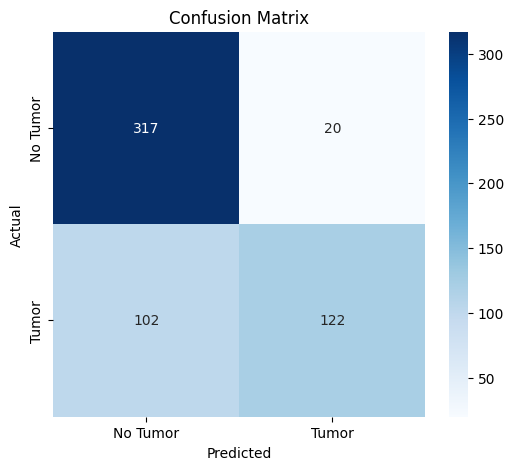

True Negative :  317
False Positive : 20
False Negative : 102
True Positive  : 122


In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative :  {tn}")
print(f"False Positive : {fp}")
print(f"False Negative : {fn}")
print(f"True Positive  : {tp}")

In [19]:
all_labels_list = []
all_probs_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = best_model(images)
        probs = torch.sigmoid(outputs)

        all_labels_list.extend(labels.cpu().numpy().flatten())
        all_probs_list.extend(probs.cpu().numpy().flatten())

all_labels_arr = np.array(all_labels_list)
all_probs_arr = np.array(all_probs_list)

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    preds_t = (all_probs_arr > t).astype(float)
    acc_t = accuracy_score(all_labels_arr, preds_t)
    prec_t = precision_score(all_labels_arr, preds_t)
    rec_t = recall_score(all_labels_arr, preds_t)
    print(f"Threshold {t:.1f} — Accuracy: {acc_t:.3f} — Precision: {prec_t:.3f} — Recall: {rec_t:.3f}")

Threshold 0.5 — Accuracy: 0.783 — Precision: 0.859 — Recall: 0.545
Threshold 0.4 — Accuracy: 0.793 — Precision: 0.821 — Recall: 0.616
Threshold 0.3 — Accuracy: 0.786 — Precision: 0.765 — Recall: 0.670
Threshold 0.2 — Accuracy: 0.775 — Precision: 0.702 — Recall: 0.759
Threshold 0.1 — Accuracy: 0.733 — Precision: 0.620 — Recall: 0.853


In [28]:
num_no_tumor = (train_df["has_tumor"] == False).sum()
num_tumor = (train_df["has_tumor"] == True).sum()

pos_weight_value = num_no_tumor / num_tumor

print(f"Number without tumor in train: {num_no_tumor}")
print(f"Number with tumor in train: {num_tumor}")
print(f"Suggested amount pos_weight: {pos_weight_value:.3f}")

Number without tumor in train: 1835
Number with tumor in train: 915
Suggested amount pos_weight: 2.005


In [21]:
model_weighted = SimpleCNN().to(device)
optimizer_weighted = torch.optim.Adam(model_weighted.parameters(), lr=0.001)

pos_weight_tensor = torch.tensor([pos_weight_value]).to(device)
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

NUM_EPOCHS = 10
best_val_loss_weighted = float("inf")
checkpoint_path_weighted = "../models/classification/weights/classifier_weighted_best.pt"

train_losses_w = []
val_losses_w = []

for epoch in range(NUM_EPOCHS):
    model_weighted.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer_weighted.zero_grad()
        outputs = model_weighted(images)
        loss = criterion_weighted(outputs, labels)
        loss.backward()
        optimizer_weighted.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss = evaluate(model_weighted, val_loader, criterion_weighted, device)

    train_losses_w.append(train_loss)
    val_losses_w.append(val_loss)

    if val_loss < best_val_loss_weighted:
        best_val_loss_weighted = val_loss
        torch.save(model_weighted.state_dict(), checkpoint_path_weighted)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Train Loss: {train_loss:.4f} — Val Loss: {val_loss:.4f}  ✅ Saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Train Loss: {train_loss:.4f} — Val Loss: {val_loss:.4f}")

Epoch 1/10 — Train Loss: 0.7670 — Val Loss: 0.6297  ✅ Saved
Epoch 2/10 — Train Loss: 0.6161 — Val Loss: 0.6245  ✅ Saved
Epoch 3/10 — Train Loss: 0.5668 — Val Loss: 0.7941
Epoch 4/10 — Train Loss: 0.5257 — Val Loss: 0.5296  ✅ Saved
Epoch 5/10 — Train Loss: 0.4618 — Val Loss: 0.9005
Epoch 6/10 — Train Loss: 0.4096 — Val Loss: 0.5697
Epoch 7/10 — Train Loss: 0.3620 — Val Loss: 0.7965
Epoch 8/10 — Train Loss: 0.3460 — Val Loss: 0.5383
Epoch 9/10 — Train Loss: 0.3054 — Val Loss: 0.7235
Epoch 10/10 — Train Loss: 0.2537 — Val Loss: 0.6461


In [26]:
best_model_weighted = SimpleCNN().to(device)
best_model_weighted.load_state_dict(torch.load(checkpoint_path_weighted))
best_model_weighted.eval()

all_labels_w = []
all_preds_w = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = best_model_weighted(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_labels_w.extend(labels.cpu().numpy().flatten())
        all_preds_w.extend(preds.cpu().numpy().flatten())

all_labels_w = np.array(all_labels_w)
all_preds_w = np.array(all_preds_w)

accuracy_w = accuracy_score(all_labels_w, all_preds_w)
precision_w = precision_score(all_labels_w, all_preds_w)
recall_w = recall_score(all_labels_w, all_preds_w)
f1_w = f1_score(all_labels_w, all_preds_w)

print("New model (Weighted Loss):")
print(f"Accuracy:  {accuracy_w:.4f}")
print(f"Precision: {precision_w:.4f}")
print(f"Recall:    {recall_w:.4f}")
print(f"F1 Score:  {f1_w:.4f}")

print("\n Previous model (without weight) for comparison")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

New model (Weighted Loss):
Accuracy:  0.7540
Precision: 0.6280
Recall:    0.9420
F1 Score:  0.7536

 Previous model (without weight) for comparison
Accuracy:  0.7825
Precision: 0.8592
Recall:    0.5446
F1 Score:  0.6667


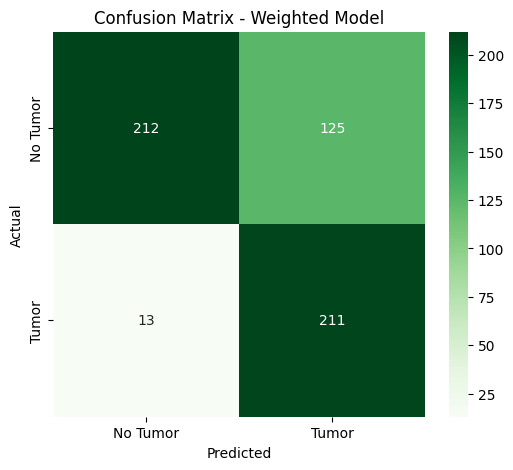

Model Weighted:
False Negative (Tumor missed.): 13  (Previously: 102)
False Positive (False alarm):          125  (Previously: 20)


In [33]:
cm_w = confusion_matrix(all_labels_w, all_preds_w)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_w, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Weighted Model")
plt.show()

tn_w, fp_w, fn_w, tp_w = cm_w.ravel()
print(f"Model Weighted:")
print(f"False Negative (Tumor missed.): {fn_w}  (Previously: 102)")
print(f"False Positive (False alarm):          {fp_w}  (Previously: 20)")